## Bank Marketing Classification Project

EN: Predicting whether a customer will subscribe to a term deposit using machine learning classification models.
TR: Bir müşterinin vadeli mevduata abone olup olmayacağını makine öğrenmesi sınıflandırma modelleriyle tahmin etme projesi.

## Dataset Overview / Veri Seti Genel Bakış
Rows / Satır: 41,188

Columns / Sütun: 21

Target Variable / Hedef Değişken: y

Source / Kaynak: UCI Machine Learning Repository


## Business Objective / İş Hedefi

EN: Help banks identify potential customers for marketing campaigns.

TR: Bankaların pazarlama kampanyalarında potansiyel müşterileri belirlemesine yardımcı olmak.

## Project Workflow / Proje Akışı
- Data Understanding
- Data Preprocessing
- Exploratory Data Analysis
- Model Building
- Model Evaluation
- Insights & Recommendations


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

In [2]:
df = pd.read_csv("bank-additional-full.csv", sep=";")
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [3]:
df.shape

(41188, 21)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [5]:
df.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [6]:
df["y"].value_counts() 
#hedef değişkenin yani y nin dağılımı incelenmiştir.
#vadeli mevduata abone olan ve olmayan müşteri sayıları hesaplanmıştır.

y
no     36548
yes     4640
Name: count, dtype: int64

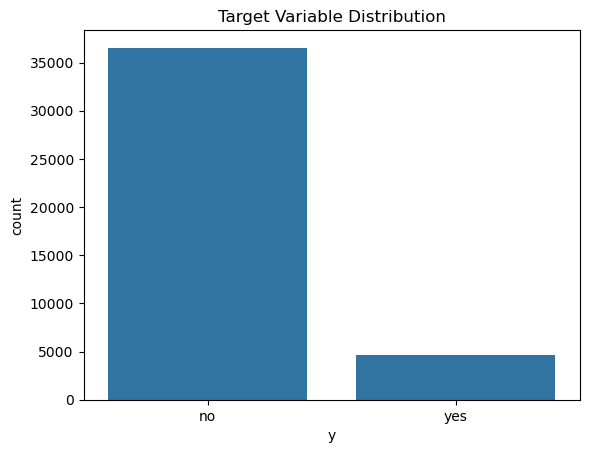

In [7]:
sns.countplot(x="y", data=df)
plt.title("Target Variable Distribution")
plt.show()

EN: As a result of the analysis, it is observed that the dataset is imbalanced.  
Because the number of customers who did not subscribe to the term deposit ("no") is significantly higher than the number of customers who subscribed ("yes").

TR: Yapılan analiz sonucunda veri setinin dengesiz olduğu görülmektedir.  
Çünkü vadeli mevduata abone olmayan müşteri sayısı ("no"), abone olan müşteri sayısından ("yes") oldukça fazladır.

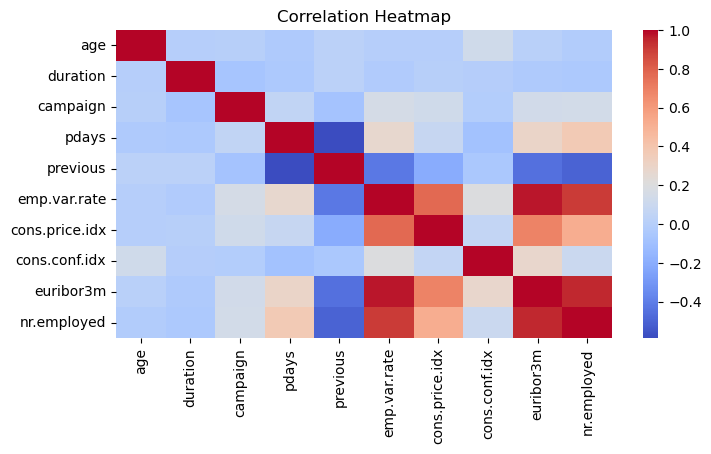

In [8]:
## Correlation Heatmap
# This heatmap shows the correlation between numerical variables in the dataset.
## Korelasyon Isı Haritası
# Bu grafik, veri setindeki sayısal değişkenler arasındaki ilişkileri göstermektedir.
plt.figure(figsize=(8,4))
sns.heatmap(df.select_dtypes(include='number').corr(), cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap")
plt.show()

EN: Dark red areas indicate strong positive relationships, dark blue areas indicate negative relationships, while light colors show weak correlations. Strong positive correlations were observed especially between euribor3m, emp.var.rate, and nr.employed. A notable negative relationship was also seen between pdays and previous.

TR: Koyu kırmızı alanlar güçlü pozitif ilişkileri, koyu mavi alanlar negatif ilişkileri, açık renkler ise zayıf korelasyonları göstermektedir. Özellikle euribor3m, emp.var.rate ve nr.employed değişkenleri arasında güçlü pozitif ilişkiler görülmüştür. Ayrıca pdays ile previous değişkenleri arasında belirgin negatif ilişki bulunmaktadır.

----------------------------------------------------------------------

## Data Preprocessing

EN: In this stage, the dataset was prepared for machine learning through encoding, feature separation, and train-test splitting.

TR: Bu aşamada veri seti, kodlama, değişken ayrımı ve eğitim-test bölme işlemleriyle makine öğrenmesine hazır hale getirilmiştir.

In [9]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = le.fit_transform(df[col])

df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,3,1,0,0,0,0,1,6,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
1,57,7,1,3,1,0,0,1,6,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
2,37,7,1,3,0,2,0,1,6,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
3,40,0,1,1,0,0,0,1,6,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
4,56,7,1,3,0,0,2,1,6,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0


EN: Categorical variables were transformed into numerical values using Label Encoding. This conversion allows machine learning algorithms to process text-based categories as numeric inputs.

TR: Kategorik değişkenler Label Encoding yöntemi kullanılarak sayısal değerlere dönüştürülmüştür. Bu dönüşüm, makine öğrenmesi algoritmalarının metin tabanlı kategorileri sayısal giriş olarak işlemesini sağlar.

In [10]:
X = df.drop("y", axis=1)
y = df["y"]

EN: The dataset was separated into independent variables (X) and the target variable (y). The "y" column was selected as the prediction target, while the remaining columns were used as input features.

TR: Veri seti bağımsız değişkenler (X) ve hedef değişken (y) olarak ayrılmıştır. "y" sütunu tahmin hedefi olarak seçilmiş, kalan sütunlar giriş özellikleri olarak kullanılmıştır.

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

EN: The dataset was divided into training and testing sets. 80% of the data was used for training and 20% for testing.

TR: Veri seti eğitim ve test kümelerine ayrılmıştır. Verilerin %80’i eğitim, %20’si ise test için kullanılmıştır.

In [12]:
print(X_train.shape)
print(X_test.shape)

(32950, 20)
(8238, 20)


EN: After the train-test split, the training set contains 32,950 rows and 20 columns, while the test set contains 8,238 rows and 20 columns.

TR: Eğitim-test ayrımından sonra eğitim veri seti 32,950 satır ve 20 sütundan, test veri seti ise 8,238 satır ve 20 sütundan oluşmaktadır.

In [13]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=3000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier()
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results.append([name, acc])

results_df = pd.DataFrame(results, columns=["Model", "Accuracy"])
results_df

c:\Users\misafir\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,Model,Accuracy
0,Logistic Regression,0.909930
1,Decision Tree,0.890265
2,Random Forest,0.913935
3,KNN,0.902282


EN: Four different classification algorithms were applied to the dataset and their accuracy scores were compared. According to the results, Random Forest achieved the highest accuracy score with 91.39%. Logistic Regression followed closely with 90.99%, while KNN also produced solid performance. Decision Tree had the lowest accuracy among the tested models. These findings indicate that ensemble-based methods such as Random Forest can provide better predictive performance on this dataset.

TR: Veri setine dört farklı sınıflandırma algoritması uygulanmış ve doğruluk oranları karşılaştırılmıştır. Sonuçlara göre en yüksek başarı oranını %91.39 ile Random Forest modeli elde etmiştir. Logistic Regression modeli %90.99 ile yakın performans göstermiştir. KNN modeli de başarılı sonuç verirken, Decision Tree modeli test edilen modeller arasında en düşük doğruluk oranına sahip olmuştur. Bu sonuçlar, Random Forest gibi topluluk temelli yöntemlerin bu veri setinde daha başarılı tahminler yapabildiğini göstermektedir.

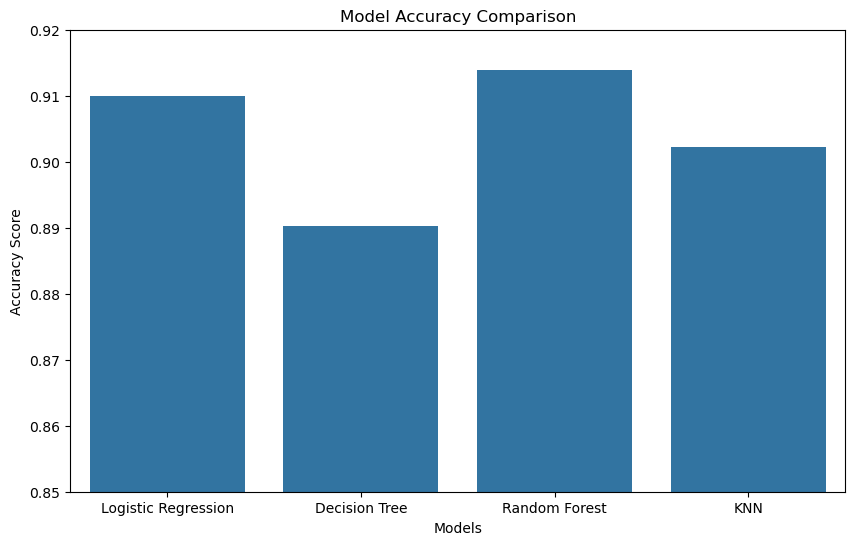

In [14]:
plt.figure(figsize=(10,6))
sns.barplot(x="Model", y="Accuracy", data=results_df)

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy Score")
plt.ylim(0.85, 0.92)

plt.show()

EN: The bar chart compares the accuracy scores of the classification algorithms applied to the dataset.
Among all models, Random Forest achieved the highest accuracy score, making it the best performing model.
Logistic Regression also produced a strong result with a score close to Random Forest.
KNN showed acceptable performance, while Decision Tree had the lowest accuracy among the tested models.
Overall, all models performed above 88%, indicating that the dataset is suitable for classification tasks.

TR: Sütun grafik, veri setine uygulanan sınıflandırma algoritmalarının doğruluk oranlarını karşılaştırmaktadır.
Tüm modeller arasında en yüksek doğruluk oranını Random Forest modeli elde etmiş ve en başarılı model olmuştur.
Logistic Regression modeli de Random Forest’a yakın güçlü bir sonuç vermiştir.
KNN modeli kabul edilebilir performans gösterirken, Decision Tree modeli test edilen modeller arasında en düşük doğruluk oranına sahip olmuştur.
Genel olarak tüm modeller %88’in üzerinde başarı göstermiştir. Bu durum veri setinin sınıflandırma işlemleri için uygun olduğunu göstermektedir.

In [15]:
## Hyperparameter Tuning with GridSearchCV
# In this step, the best parameters for the Random Forest model were searched automatically.
## GridSearchCV ile Hiperparametre Optimizasyonu
# Bu adımda, Random Forest modeli için en iyi parametreler otomatik olarak aranmıştır.

from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(
    RandomForestClassifier(),
    param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)

Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Best Score: 0.9144462417883586


EN: GridSearchCV results showed that the best Random Forest model uses 200 trees with a maximum depth of 20. The cross-validation score of 91.44% indicates stable and strong model performance.

TR: GridSearchCV sonuçlarına göre en iyi Random Forest modeli 200 ağaç ve maksimum 20 derinlik ile elde edilmiştir. %91.44 çapraz doğrulama skoru modelin güçlü ve kararlı performans gösterdiğini ortaya koymaktadır.

## Random Forest Re-training

In [16]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=2,
    random_state=42
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# Random Forest model was retrained using the best parameters obtained from GridSearchCV for detailed evaluation.

# Random Forest modeli, GridSearchCV ile bulunan en iyi parametreler kullanılarak detaylı değerlendirme için yeniden eğitilmiştir.

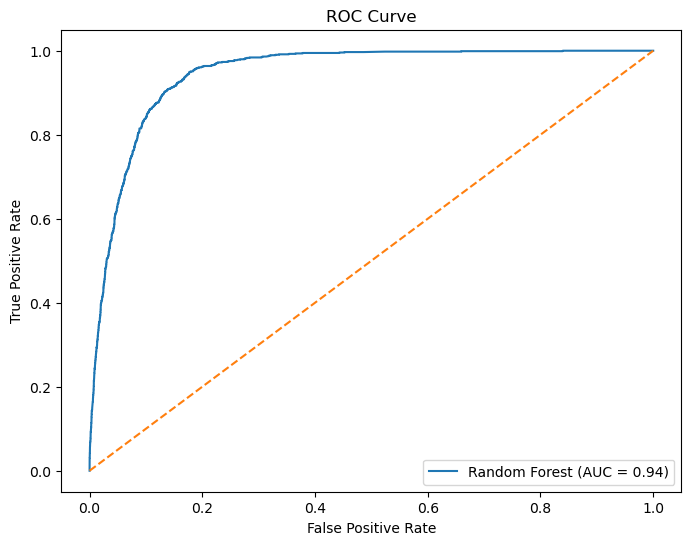

In [17]:
## ROC Curve Analysis
# This graph shows the classification performance of the Random Forest model.
## ROC Eğrisi Analizi
# Bu grafik, Random Forest modelinin sınıflandırma performansını göstermektedir.

from sklearn.metrics import roc_curve, auc

y_prob = rf.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label="Random Forest (AUC = %0.2f)" % roc_auc)
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

EN: The ROC curve shows that the Random Forest model performed very well in distinguishing customer classes. The AUC score of 0.94 indicates strong classification performance.

TR: ROC eğrisi, Random Forest modelinin müşteri sınıflarını ayırt etmede oldukça başarılı olduğunu göstermektedir. 0.94 AUC skoru güçlü bir sınıflandırma performansına işaret etmektedir.

## Confusion Matrix

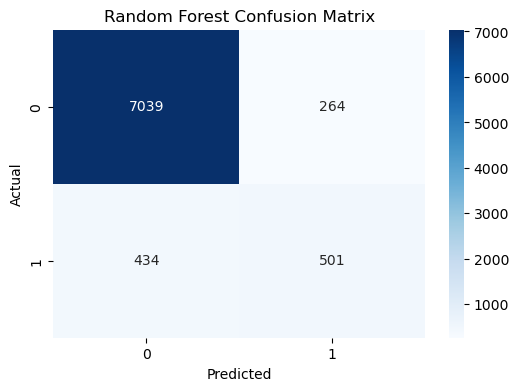

In [18]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

EN: In the confusion matrix, class 0 represents customers who did not subscribe ("no"), while class 1 represents customers who subscribed ("yes").
Most observations were predicted correctly, indicating that the Random Forest model achieved strong performance.
The model was more successful in identifying class 0 customers than class 1 customers.

TR: Confusion matrix içerisinde 0 sınıfı vadeli mevduata abone olmayan müşterileri ("no"), 1 sınıfı ise abone olan müşterileri ("yes") temsil etmektedir.
Gözlemlerin büyük çoğunluğu doğru tahmin edilmiştir, bu da Random Forest modelinin güçlü performans gösterdiğini göstermektedir.
Model, 0 sınıfındaki müşterileri belirlemede 1 sınıfına göre daha başarılı olmuştur.

## Classification Report

In [19]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.94      0.96      0.95      7303
           1       0.65      0.54      0.59       935

    accuracy                           0.92      8238
   macro avg       0.80      0.75      0.77      8238
weighted avg       0.91      0.92      0.91      8238



EN: The classification report shows that the model achieved 92% overall accuracy.
Class 0 ("no") was predicted with high success, while class 1 ("yes") had lower prediction performance.
This indicates that the model performs well overall, but has more difficulty identifying customers who subscribed.

TR: Classification report sonucuna göre model genel olarak %92 doğruluk oranı elde etmiştir.
0 sınıfı ("no") yüksek başarıyla tahmin edilirken, 1 sınıfı ("yes") için tahmin performansı daha düşük kalmıştır.
Bu durum, modelin genel olarak başarılı olduğunu ancak abone olan müşterileri belirlemede daha fazla zorlandığını göstermektedir.

## Feature Importance

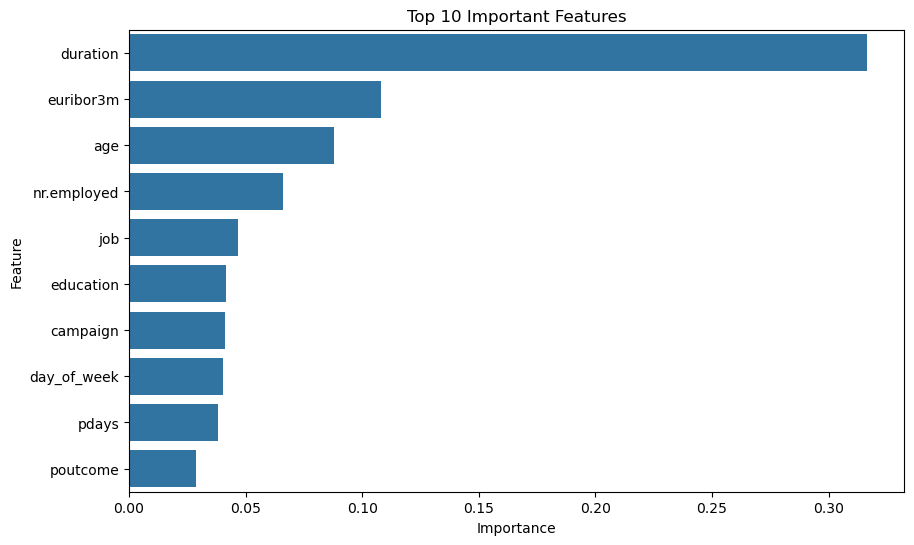

In [20]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=importance.head(10))

plt.title("Top 10 Important Features")
plt.show()

 EN: The feature importance graph shows which variables had the greatest impact on Random Forest predictions.
 Duration was the most influential variable, followed by euribor3m, age, and nr.employed.
 These results indicate that both customer interaction factors and economic conditions play an important role in predicting term deposit subscription.

 TR: Değişken önem grafiği, Random Forest tahminlerinde hangi değişkenlerin daha etkili olduğunu göstermektedir.
 En önemli değişken duration olurken, onu euribor3m, age ve nr.employed takip etmiştir.
 Sonuçlar, hem müşteri etkileşimi hem de ekonomik koşulların abonelik tahmininde önemli rol oynadığını göstermektedir.

## Executive Summary

EN:

• The Bank Marketing dataset was analyzed using multiple classification models.  
• Random Forest delivered the best overall performance with over 91% accuracy.  
• ROC Curve, Confusion Matrix, and Feature Importance confirmed model reliability.  
• Machine learning can support customer targeting and campaign efficiency in banking.  

TR:

• Bank Marketing veri seti birden fazla sınıflandırma modeli ile analiz edilmiştir.  
• En başarılı performansı %91’in üzerinde doğruluk oranı ile Random Forest modeli göstermiştir.  
• ROC Curve, Confusion Matrix ve Değişken Önem Analizi model güvenilirliğini doğrulamıştır.  
• Makine öğrenmesi, bankacılıkta müşteri hedefleme ve kampanya verimliliğini destekleyebilir.

## Recommendations / Öneriler

EN:

• Random Forest should be preferred in future campaign planning, as it achieved the highest accuracy (91%+) and strong AUC performance.  
• Since duration was the most important variable, improving call quality and customer engagement may increase subscription success.  
• Economic indicators such as euribor3m and nr.employed should be considered when determining campaign timing.  
• Because the dataset is imbalanced, future studies may apply SMOTE or similar techniques to improve prediction of the subscribed class.  

TR:

• En yüksek doğruluk oranı (%91+) ve güçlü AUC performansı nedeniyle gelecekteki kampanya planlamalarında Random Forest modeli tercih edilmelidir.  
• Duration değişkeni en önemli faktör olduğundan, çağrı kalitesi ve müşteri etkileşimini artırmak abonelik başarısını yükseltebilir.  
• Kampanya zamanlaması belirlenirken euribor3m ve nr.employed gibi ekonomik göstergeler dikkate alınmalıdır.  
• Veri seti dengesiz olduğu için gelecekteki çalışmalarda SMOTE benzeri yöntemler kullanılarak abone olan sınıfın tahmin başarısı artırılabilir.